In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest

from ucimlrepo import fetch_ucirepo

In [47]:
air_quality = fetch_ucirepo(id=360)
air_quality

{'data': {'ids': None,
  'features':            Date      Time  CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  \
  0     3/10/2004  18:00:00     2.6         1360       150      11.9   
  1     3/10/2004  19:00:00     2.0         1292       112       9.4   
  2     3/10/2004  20:00:00     2.2         1402        88       9.0   
  3     3/10/2004  21:00:00     2.2         1376        80       9.2   
  4     3/10/2004  22:00:00     1.6         1272        51       6.5   
  ...         ...       ...     ...          ...       ...       ...   
  9352   4/4/2005  10:00:00     3.1         1314      -200      13.5   
  9353   4/4/2005  11:00:00     2.4         1163      -200      11.4   
  9354   4/4/2005  12:00:00     2.4         1142      -200      12.4   
  9355   4/4/2005  13:00:00     2.1         1003      -200       9.5   
  9356   4/4/2005  14:00:00     2.2         1071      -200      11.9   
  
        PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  \
  0              1046      

In [48]:
data = air_quality.data['features'].copy()
data

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,3/10/2004,18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
1,3/10/2004,19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2,3/10/2004,20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
3,3/10/2004,21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
4,3/10/2004,22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9352,4/4/2005,10:00:00,3.1,1314,-200,13.5,1101,472,539,190,1374,1729,21.9,29.3,0.7568
9353,4/4/2005,11:00:00,2.4,1163,-200,11.4,1027,353,604,179,1264,1269,24.3,23.7,0.7119
9354,4/4/2005,12:00:00,2.4,1142,-200,12.4,1063,293,603,175,1241,1092,26.9,18.3,0.6406
9355,4/4/2005,13:00:00,2.1,1003,-200,9.5,961,235,702,156,1041,770,28.3,13.5,0.5139


In [49]:
df = data[['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']].copy()
df.head()

,CO(GT),C6H6(GT),NOx(GT),NO2(GT)
0,2.6,11.9,166,113
1,2.0,9.4,103,92
2,2.2,9.0,131,114
3,2.2,9.2,172,122
4,1.6,6.5,131,116


In [50]:
df.dtypes

CO(GT)      float64
C6H6(GT)    float64
NOx(GT)       int64
NO2(GT)       int64
dtype: object

In [51]:
df.isna().sum()

CO(GT)      0
C6H6(GT)    0
NOx(GT)     0
NO2(GT)     0
dtype: int64

In [52]:
df.corr()

,CO(GT),C6H6(GT),NOx(GT),NO2(GT)
CO(GT),1.000000,-0.031378,0.526451,0.671127
C6H6(GT),-0.031378,1.000000,-0.001174,-0.010992
NOx(GT),0.526451,-0.001174,1.000000,0.817139
NO2(GT),0.671127,-0.010992,0.817139,1.000000


In [53]:
# Parameters for isolation forest

n_estimators = 100 # number of trees in the forest
contamination = 0.01 # Percentage of outliers in the data
sample_size = 256 # Max samples used for sampling

In [54]:
model = IsolationForest(n_estimators=n_estimators, contamination=contamination, max_samples=sample_size, random_state=42)

In [55]:
model.fit(df)

# Predict Anomalies
anomaly_labels = model.predict(df)

# Add anomaly labels to the dataframe
df.loc[:, 'anomaly'] = anomaly_labels

# Anomaly lables will be -1 for anomalies and 1 normal data points

In [56]:
df['anomaly'].value_counts()

anomaly
 1    9263
-1      94
Name: count, dtype: int64

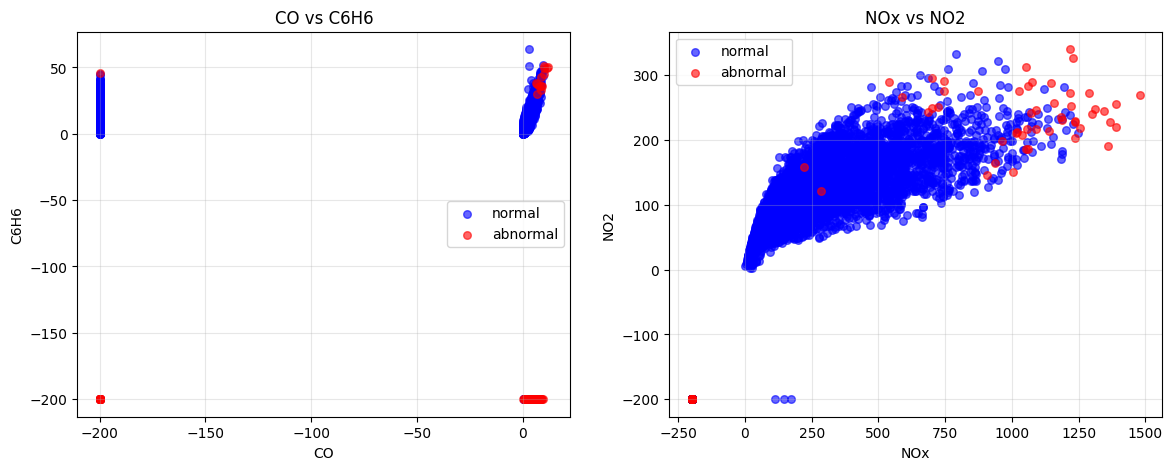

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

normal = df[df['anomaly'] == 1]
abnormal = df[df['anomaly'] == -1]

# Plot 1 - CO vs C6H6
axes[0].scatter(normal['CO(GT)'], normal['C6H6(GT)'], color='blue', label='normal', alpha=0.6, s=30)
axes[0].scatter(abnormal['CO(GT)'], abnormal['C6H6(GT)'], color='red', label='abnormal', alpha=0.6, s=30)
axes[0].set_xlabel('CO')
axes[0].set_ylabel('C6H6')
axes[0].legend()
axes[0].set_title('CO vs C6H6')
axes[0].grid(True, alpha=0.3)

# Plot 2 - NOX vs NO2
axes[1].scatter(normal['NOx(GT)'], normal['NO2(GT)'], color='blue', label='normal', alpha=0.6, s=30)
axes[1].scatter(abnormal['NOx(GT)'], abnormal['NO2(GT)'], color='red', label='abnormal', alpha=0.6, s=30)
axes[1].set_xlabel('NOx')
axes[1].set_ylabel('NO2')
axes[1].legend()
axes[1].set_title('NOx vs NO2')
axes[1].grid(True, alpha=0.3)

In [64]:
import joblib

model_path = './isolation_forest_model.pkl'
joblib.dump(model, model_path)

['./isolation_forest_model.pkl']